# Optimal Experimental Design: Choosing the Rotation Angles of a DRRP Polarimeter
_written by Jaren N. Ashcraft_

In the [companion tutorial](BayesianPolarimetry.ipynb) we *calibrated* a dual-rotating-retarder (DRRP) polarimeter: given a fixed set of retarder rotation angles, we recovered the instrument parameters and their posterior covariance. That notebook took the **measurement schedule** — the list of commanded rotation angles $\{\theta_i\}$ — as a given, a uniform sweep $\theta \in [0,\pi]$.

But the schedule is a *design choice*, and it is one of the few things an experimenter fully controls. Different schedules spread the sample's Mueller elements across the modulation harmonics differently, and therefore produce **different posterior covariances**. This notebook asks the optimal-experimental-design question:

> Which rotation angles should we command so that the calibration is as precise as possible?

Two things have to be settled before that question is even well-posed:

1. **Gauge.** The detected power is invariant under a *global rotation* of the whole instrument — rotating the generator polarizer, both retarders and the analyzer by a common angle changes nothing, because the input is unpolarized and the detector sees only total power. That invariance is a **flat direction** in the likelihood: the Fisher matrix is singular, and the affected marginals are set by the prior rather than the data. We remove it by **fixing the generator polarizer's transmission axis**, pinning the reference frame. This is the first thing we do below.
2. **Coupling.** The two retarders are usually *geared*: $\theta_2 = G\,\theta_1$ with an integer ratio $G$. That is a design choice too. The last third of the notebook asks whether a **non-linear gear ratio** $\theta_2 = g(\theta_1)$, or fully **independent** retarder angles, buys additional precision.

The key object throughout is the **Fisher information matrix** $\mathbf{F}$. Under the Laplace approximation it is the Hessian of the negative log-posterior at the solution, and its inverse is the parameter covariance $\mathbf{C}=\mathbf{F}^{-1}$. Crucially, $\mathbf{F}$ depends on the schedule through the Jacobian of the model outputs with respect to the parameters:

$$\mathbf{F}(\{\theta_i\}) \;=\; \frac{1}{\sigma^2}\,\mathbf{J}^\top \mathbf{J} \;+\; \mathbf{F}_{\text{prior}},\qquad J_{ik}=\frac{\partial\, m(\theta_i)}{\partial\, p_k}.$$

Because `katsu` is built on `jax`, $\mathbf{F}$ is a **differentiable function of the schedule** (and of the gear coupling). We can therefore descend a scalar summary of the covariance directly, using the same `optax` machinery the calibration used — only now the *rotation angles* are the free variables and the instrument parameters are held at their nominal values. Two classic design criteria:

| criterion | scalar objective | geometric meaning | matches |
| --- | --- | --- | --- |
| **A-optimality** | $\operatorname{tr}\mathbf{C}$ | sum of marginal variances | "tighter marginal bounds" |
| **D-optimality** | $-\log\det\mathbf{F}$ | volume of the joint confidence ellipsoid | "minimum measurement covariance" |

A caveat worth stating up front: $\mathbf{F}$ depends on the (unknown) true parameters, so we optimize at our best *nominal* guess of the instrument. This is **locally optimal design** — perfectly standard, and in practice one iterates design ↔ calibration.

In [1]:
import os

from katsu.katsu_math import np, set_backend_to_jax
set_backend_to_jax()  # must happen before we build any models

import jax
import optax
import blackjax
import pandas as pd
import matplotlib.pyplot as plt

from katsu.models import Model, LinearDiattenuator, MuellerMatrix
from katsu.mueller import linear_retarder

## The rotating-retarder element

This is the same small custom element from the calibration notebook. A DRRP retarder's fast axis at each measurement state is `start_angle + rotation`, where `rotation` is the *commanded* angle read off the stage encoders and `start_angle` is the scalar mounting offset. Only the scalar physical parameters are differentiable leaves; the `rotation` array rides along as data.

The difference in *this* notebook is what we differentiate with respect to: we will take gradients through the `rotation` array itself.

In [2]:
class RotatingRetarder(MuellerMatrix):
    '''Linear retarder whose fast axis is ``start_angle + rotation``.

    ``rotation`` is the known commanded fast-axis angle at every measurement
    state; ``start_angle`` is the unknown scalar mounting offset.
    '''

    start_angle: float
    retardance: float
    rotation: np.ndarray
    shape: tuple

    def __init__(self, start_angle, retardance, rotation):
        self.start_angle = start_angle
        self.retardance = retardance
        self.rotation = rotation
        self.shape = rotation.shape

    @property
    def matrix(self):
        return linear_retarder(
            self.start_angle + self.rotation, self.retardance, shape=self.shape
        )

## The rotational gauge freedom

Before optimizing anything, we have to deal with the invariance flagged in the introduction. The generator polarizer, the two retarders and the analyzer all carry an *angle*. But the input light is unpolarized and the detector measures only total power, so a **common rotation of all four elements** leaves every measurement identical. In parameter space that is a direction along which the likelihood is perfectly flat — the data carry *zero* information about it.

We can see it directly. Build the Jacobian of the detected power with respect to all **six** raw parameters — generator-polarizer axis $p_1$, retardances $\delta_{1,2}$, start angles $\theta_{1,2}$, analyzer axis $p_2$ — and look at the eigenspectrum of the likelihood Fisher matrix $\mathbf{J}^\top\mathbf{J}$.

In [3]:
# Diagnostic: expose the rotational gauge freedom of the six-parameter model.
_order6 = ["pol_gen.transmission_axis", "ret1.retardance", "ret1.start_angle",
           "ret2.retardance", "ret2.start_angle", "pol_ana.transmission_axis"]
_nominal6 = np.radians(np.array([2.0, 95.0, 3.0, 88.0, -4.0, -3.0]))
_baseline = np.linspace(0, np.pi, 64)


def _predict6(pvec, sched):
    p = {k: pvec[i] for i, k in enumerate(_order6)}
    system = Model([
        ("pol_gen", LinearDiattenuator(p["pol_gen.transmission_axis"], 0.0)),
        ("ret1", RotatingRetarder(p["ret1.start_angle"], p["ret1.retardance"], sched)),
        ("ret2", RotatingRetarder(p["ret2.start_angle"], p["ret2.retardance"], 5 * sched)),
        ("pol_ana", LinearDiattenuator(p["pol_ana.transmission_axis"], 0.0)),
    ])
    return system.forward(np.array([1.0, 0.0, 0.0, 0.0]))[..., 0]


_J6 = jax.jacrev(lambda v: _predict6(v, _baseline))(_nominal6)     # (N, 6)
_evals, _evecs = np.linalg.eigh(_J6.T @ _J6)                        # likelihood Fisher

print("six-parameter likelihood-Fisher eigenvalues:")
print("  " + "  ".join(f"{float(e):.2e}" for e in jax.device_get(_evals)))
print("\nflat-direction eigenvector (smallest eigenvalue):")
for k, c in zip(_order6, jax.device_get(_evecs[:, 0])):
    print(f"  {k:28s} {float(c):+.3f}")

six-parameter likelihood-Fisher eigenvalues:
  9.83e-16  5.01e-01  6.65e-01  1.08e+00  1.17e+01  1.44e+01

flat-direction eigenvector (smallest eigenvalue):
  pol_gen.transmission_axis    -0.500
  ret1.retardance              -0.000
  ret1.start_angle             -0.500
  ret2.retardance              +0.000
  ret2.start_angle             -0.500
  pol_ana.transmission_axis    -0.500


One eigenvalue sits at ~$10^{-15}$ while the rest are $\mathcal{O}(1)$ — some fifteen orders of magnitude below its neighbours, so the likelihood is numerically singular. Its eigenvector is $(\,{\pm}0.5,\,0,\,{\pm}0.5,\,0,\,{\pm}0.5,\,{\pm}0.5\,)$ (the overall sign is arbitrary) — equal-magnitude weight on **all four angle parameters** ($p_1,\theta_1,\theta_2,p_2$) and zero on the two retardances. That is exactly the global-rotation direction $\delta p_1=\delta\theta_1=\delta\theta_2=\delta p_2$: shift every angle together and nothing changes. The retardances are rotation-invariant, so they sit it out.

Left in the model, this flat direction contaminates the marginals of *all four* angles: with no data to pin the overall frame, the four angles can only be pinned *relative to each other*, and each individual marginal inflates to whatever the prior allows. That is a property of the parameterization, not of the schedule — **no choice of rotation angles can fix it.**

The standard remedy is to **fix the gauge**: declare one angle to be the reference and hold it constant. The natural choice is the generator polarizer, whose axis *defines* the plane of the incoming polarized beam. From here on `pol_gen.transmission_axis` is a fixed constant, not a free parameter, and we calibrate the remaining **five**. With the frame pinned, the other angles become measurable against it, and — as we will see — their posteriors are set by the *data* rather than the prior.

## The instrument as a pure function of (parameters, schedules)

To differentiate the Fisher matrix with respect to the schedule, we express the detected power as a plain function of the parameter vector `pvec` (now **five** entries) and the two retarder schedules. We keep retarder 1 and retarder 2 as **independent** commanded-angle arrays `sched1`, `sched2`; the familiar linear gear is just the special case `sched2 = GEAR * sched1`, which we use until the final section. The observed intensity is the top-left element of the system Mueller matrix acting on the unpolarized input.

We fix the five parameters at a **nominal** instrument — polarizer a couple of degrees off horizontal, retardances a few degrees from quarter-wave, small mounting offsets — exactly the "truth" the calibration notebook recovered. The design is optimized at this nominal point.

In [4]:
N = 64                       # number of measurement states
GEAR = 5                     # nominal gear ratio: retarder-2 sweeps 5x faster than retarder-1
sigma = 0.01                 # per-measurement read noise
stokes = np.array([1.0, 0.0, 0.0, 0.0])  # unpolarized input

# --- Gauge fix -------------------------------------------------------------
# The generator polarizer's transmission axis is held FIXED: it defines the
# reference frame and removes the global-rotation flat direction diagnosed
# above. It is therefore no longer a calibration parameter.
POL_GEN_AXIS = np.radians(2.0)

# The five remaining calibration parameters, in a fixed order (jax flattens in
# this order).
order = [
    "ret1.retardance", "ret1.start_angle",
    "ret2.retardance", "ret2.start_angle",
    "pol_ana.transmission_axis",
]

# Nominal instrument to design around (radians).
nominal = np.array([
    np.radians(95.0),   # retarder-1 retardance
    np.radians(3.0),    # retarder-1 start angle
    np.radians(88.0),   # retarder-2 retardance
    np.radians(-4.0),   # retarder-2 start angle
    np.radians(-3.0),   # analyzer polarizer axis
])

# Weakly-informative priors centred on the *design* instrument (as in calibration).
prior_mu = {
    "pol_ana.transmission_axis": 0.0,
    "ret1.retardance": np.pi / 2,
    "ret2.retardance": np.pi / 2,
    "ret1.start_angle": 0.0,
    "ret2.start_angle": 0.0,
}
prior_sigma = 0.2                                     # ~11 deg
prior_precision = np.eye(len(order)) / prior_sigma ** 2   # F_prior


def build_system(pvec, sched1, sched2):
    '''Assemble the DRRP for a parameter vector and the two retarder schedules.

    ``sched1`` / ``sched2`` are the commanded fast-axis angles of retarder 1 and
    retarder 2 at every measurement state. Keeping them independent lets us
    explore couplings beyond the fixed linear gear ``sched2 = GEAR * sched1``.
    The generator polarizer is held at the fixed gauge angle ``POL_GEN_AXIS``.
    '''
    p = {k: pvec[i] for i, k in enumerate(order)}
    return Model([
        ("pol_gen", LinearDiattenuator(POL_GEN_AXIS, 0.0)),
        ("ret1", RotatingRetarder(p["ret1.start_angle"], p["ret1.retardance"], sched1)),
        ("ret2", RotatingRetarder(p["ret2.start_angle"], p["ret2.retardance"], sched2)),
        ("pol_ana", LinearDiattenuator(p["pol_ana.transmission_axis"], 0.0)),
    ])


def predict(pvec, sched1, sched2):
    '''Detected power at every measurement state.'''
    return build_system(pvec, sched1, sched2).forward(stokes)[..., 0]

## The Fisher information matrix as a function of the schedule

We build $\mathbf{F}$ from the Jacobian of `predict` with respect to the five parameters, evaluated at the nominal instrument. `jax.jacrev` gives us the $N\times 5$ Jacobian; the Fisher matrix is $\mathbf{J}^\top\mathbf{J}/\sigma^2$ plus the prior precision. The predicted parameter covariance is $\mathbf{C}=\mathbf{F}^{-1}$, and the **marginal 1-$\sigma$ bounds** are $\sqrt{\operatorname{diag}\mathbf{C}}$.

`fisher` now takes the two retarder schedules separately; the baseline below is the uniform sweep with retarder 2 linearly geared, `sched2 = GEAR * sched1`. Every step is differentiable in both schedules, so the whole covariance is too.

In [5]:
def fisher(sched1, sched2, pvec=nominal):
    J = jax.jacrev(lambda v: predict(v, sched1, sched2))(pvec)   # (N, 5)
    return (J.T @ J) / sigma ** 2 + prior_precision              # (5, 5)


def marginal_sigmas_deg(sched1, sched2):
    C = np.linalg.inv(fisher(sched1, sched2))
    return np.degrees(np.sqrt(np.diag(C)))


# Baseline schedule: the uniform sweep used in the calibration notebook, with
# retarder 2 linearly geared at GEAR x retarder 1.
baseline = np.linspace(0, np.pi, N)

print("baseline marginal 1-sigma [deg]:")
for k, s in zip(order, marginal_sigmas_deg(baseline, GEAR * baseline)):
    print(f"  {k:28s} {float(s):7.3f}")

baseline marginal 1-sigma [deg]:


  ret1.retardance                0.742
  ret1.start_angle               0.256
  ret2.retardance                0.757
  ret2.start_angle               0.599
  pol_ana.transmission_axis      0.681


## Two design criteria

We now define the two scalar objectives. **A-optimality** literally minimizes the sum of the marginal variances — the most direct reading of "tighter marginal bounds." **D-optimality** maximizes $\log\det\mathbf{F}$, which minimizes the volume of the joint confidence ellipsoid $\propto (\det\mathbf{F})^{-1/2}$ — a global "minimum covariance" criterion that, unlike the trace, is not dominated by whichever single parameter happens to have the largest variance.

In [6]:
def a_optimality(sched):
    '''Sum of marginal variances = trace of the covariance (linear gear).'''
    return np.trace(np.linalg.inv(fisher(sched, GEAR * sched)))


def neg_logdet_fisher(sched):
    '''D-optimality objective (linear gear): minimize -log det F  <=>  shrink the joint ellipsoid.'''
    return -np.linalg.slogdet(fisher(sched, GEAR * sched))[1]

## Optimizing the schedule for tighter marginals (A-optimality)

We descend `a_optimality` with Adam, starting from the uniform baseline schedule and letting all `N` rotation angles move freely (a retarder's fast axis is periodic mod $\pi$, so unbounded angles are fine). This is the identical optimization pattern the calibration used — only the free variable has changed from *instrument parameters* to *rotation angles*.

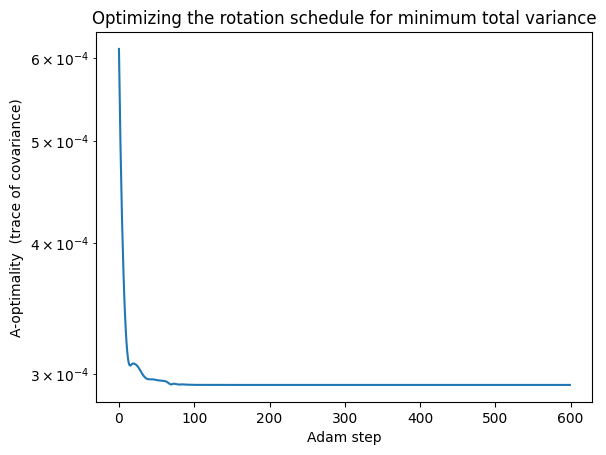

In [7]:
sched = baseline
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(sched)

value_and_grad = jax.jit(jax.value_and_grad(a_optimality))

a_losses = []
for step in range(600):
    loss, grads = value_and_grad(sched)
    updates, opt_state = optimizer.update(grads, opt_state)
    sched = optax.apply_updates(sched, updates)
    a_losses.append(float(loss))

sched_A = sched

plt.figure()
plt.plot(a_losses)
plt.xlabel("Adam step")
plt.ylabel("A-optimality  (trace of covariance)")
plt.title("Optimizing the rotation schedule for minimum total variance")
plt.yscale("log")
plt.show()

### What moved, and what didn't

Comparing the baseline and A-optimal schedules parameter by parameter is revealing — and it looks quite different now that the gauge is fixed. With the generator polarizer pinning the frame, **every** direction carries information, so the schedule has leverage on all five parameters, not just the retardances.

The **retardances** $\delta_1,\delta_2$ — the parameters the modulation curve constrains most strongly — still tighten the most. But the **start angles** $\theta_1,\theta_2$ and the **analyzer axis** $p_2$, which in the un-gauged six-parameter model were pinned near the prior width ($\sim\!5.7^\circ$) by the flat rotation direction, now start out **sub-degree** and tighten further under the optimized schedule. That is the whole point of fixing the gauge: measurements that were previously wasted on an unobservable overall rotation are now spent constraining real, relative angles.

The one direction that barely moves is $\theta_1$: retarder 1 is closest to the fixed reference polarizer, so its start angle is already the best-determined angle in the baseline and there is little left to gain.

parameter                      baseline  A-optimal    change
  ret1.retardance                0.742      0.484    -34.7%
  ret1.start_angle               0.256      0.233     -8.7%
  ret2.retardance                0.757      0.535    -29.4%
  ret2.start_angle               0.599      0.427    -28.7%
  pol_ana.transmission_axis      0.681      0.452    -33.6%


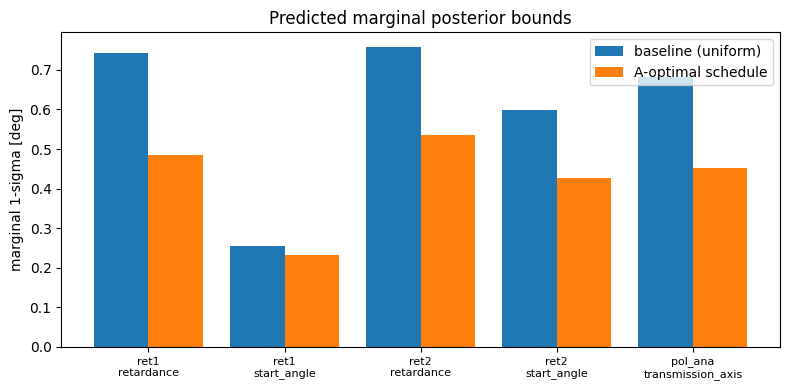

In [8]:
sig0 = marginal_sigmas_deg(baseline, GEAR * baseline)
sigA = marginal_sigmas_deg(sched_A, GEAR * sched_A)

print(f"{'parameter':28s} {'baseline':>10s} {'A-optimal':>10s} {'change':>9s}")
for k, a, b in zip(order, sig0, sigA):
    print(f"  {k:26s} {float(a):9.3f} {float(b):10.3f} {100*(float(b)/float(a)-1):+8.1f}%")

x = np.arange(len(order))
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, jax.device_get(sig0), width=0.4, label="baseline (uniform)")
plt.bar(x + 0.2, jax.device_get(sigA), width=0.4, label="A-optimal schedule")
plt.xticks(x, [k.replace(".", "\n") for k in order], fontsize=8)
plt.ylabel("marginal 1-sigma [deg]")
plt.title("Predicted marginal posterior bounds")
plt.legend()
plt.tight_layout()
plt.show()

### Where does the optimal schedule place its measurements?

Plotting the commanded retarder-1 angles, sorted, shows how the optimizer redistributes the sampling away from the perfectly uniform sweep — clustering measurement states where the retardance harmonics carry the most information.

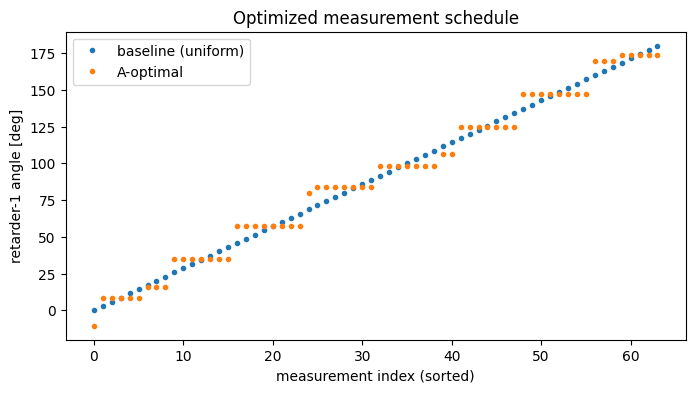

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(np.degrees(np.sort(baseline)), ".", label="baseline (uniform)")
plt.plot(np.degrees(np.sort(sched_A)), ".", label="A-optimal")
plt.xlabel("measurement index (sorted)")
plt.ylabel("retarder-1 angle [deg]")
plt.title("Optimized measurement schedule")
plt.legend()
plt.show()

## Minimum joint covariance (D-optimality)

For completeness we also optimize the D-optimality criterion, which shrinks the *joint* confidence ellipsoid rather than the sum of marginals. The volume of that ellipsoid scales as $(\det\mathbf{F})^{-1/2}$, so the improvement factor is $\exp\!\big[-\tfrac12(\log\det\mathbf{F}_{\text{opt}}-\log\det\mathbf{F}_{\text{base}})\big]$.

In [10]:
sched = baseline
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(sched)
vg_D = jax.jit(jax.value_and_grad(neg_logdet_fisher))

for step in range(800):
    loss, grads = vg_D(sched)
    updates, opt_state = optimizer.update(grads, opt_state)
    sched = optax.apply_updates(sched, updates)

sched_D = sched

logdet_base = float(-neg_logdet_fisher(baseline))
logdet_D = float(-neg_logdet_fisher(sched_D))
vol_ratio = float(np.exp(-0.5 * (logdet_D - logdet_base)))
print(f"log det F : baseline {logdet_base:.3f}  ->  D-optimal {logdet_D:.3f}")
print(f"joint confidence-ellipsoid volume shrinks by ~{1/vol_ratio:.1f}x")

log det F : baseline 48.786  ->  D-optimal 51.378
joint confidence-ellipsoid volume shrinks by ~3.7x


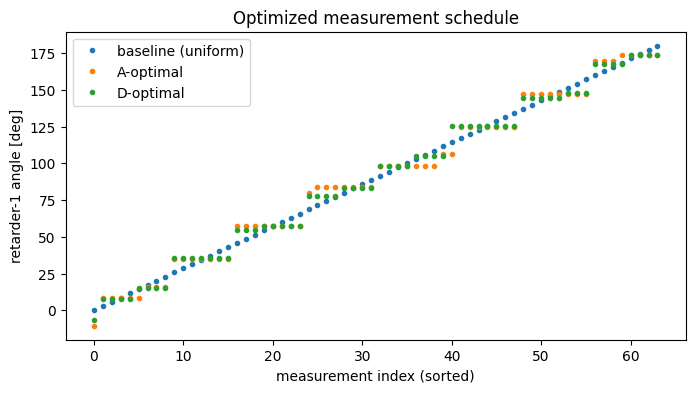

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(np.degrees(np.sort(baseline)), ".", label="baseline (uniform)")
plt.plot(np.degrees(np.sort(sched_A)), ".", label="A-optimal")
plt.plot(np.degrees(np.sort(sched_D)), ".", label="D-optimal")
plt.xlabel("measurement index (sorted)")
plt.ylabel("retarder-1 angle [deg]")
plt.title("Optimized measurement schedule")
plt.legend()
plt.show()

## Beyond a fixed gear ratio: shaping the retarder-2 motion

Everything so far kept retarder 2 rigidly geared to retarder 1, $\theta_2 = G\,\theta_1$ with $G=5$, and only chose *where* to sample retarder 1. The integer gear is a mechanical convenience — one motor drives both stages — but it is also a **design constraint**, and constraints cost information. Two ways to relax it, in increasing order of hardware flexibility:

**Method 1 — a non-linear gear ratio $\theta_2 = g(\theta_1)$.** Keep retarder 2 *slaved* to retarder 1 (still one master rotation), but let the coupling be a smooth non-linear map instead of a straight line. The **instantaneous gear ratio** $r(\theta_1)=\mathrm{d}\theta_2/\mathrm{d}\theta_1$ is then a function of angle rather than the constant $G$. We parameterize it with a handful of harmonics,
$$g(\theta_1)=G\,\theta_1+\sum_{k=1}^{K}\Big[a_k\sin(2k\theta_1)+b_k\big(1-\cos 2k\theta_1\big)\Big],\qquad r(\theta_1)=G+\sum_{k=1}^{K}2k\big[a_k\cos 2k\theta_1+b_k\sin 2k\theta_1\big],$$
and optimize the $2K$ coefficients $\{a_k,b_k\}$ (all zero recovers the linear gear) **jointly** with the retarder-1 samples. This is realizable in hardware as a shaped cam or, more simply, a programmed follower stage — you are still commanding a single degree of freedom, just with an angle-dependent ratio.

**Method 2 — fully independent angles.** Drop the coupling entirely: let $\theta_1^{(i)}$ and $\theta_2^{(i)}$ be free at every measurement ($2N$ variables). This needs two independently programmable stages and is the **information ceiling** — it tells us how much the gearing constraint was ever costing us.

Both are the same differentiable-Fisher optimization; only the free variables change. We compare all four designs (baseline, linear-gear D-optimal, non-linear gear, independent) by D-optimality.

In [12]:
K = 4   # number of harmonics in the non-linear gear


def gear_map(theta1, coeffs):
    '''Non-linear gear: retarder-2 angle as a smooth function of retarder-1 angle.

    theta2 = GEAR*theta1 + sum_k [a_k sin(2k theta1) + b_k (1 - cos 2k theta1)].
    coeffs = zeros recovers the linear gear theta2 = GEAR * theta1.
    '''
    a, b = coeffs[:K], coeffs[K:]
    out = GEAR * theta1
    for k in range(1, K + 1):
        out = out + a[k - 1] * np.sin(2 * k * theta1) + b[k - 1] * (1 - np.cos(2 * k * theta1))
    return out


def gear_ratio(theta1, coeffs):
    '''Instantaneous gear ratio d(theta2)/d(theta1) as a function of angle.'''
    a, b = coeffs[:K], coeffs[K:]
    out = GEAR * np.ones_like(theta1)
    for k in range(1, K + 1):
        out = out + 2 * k * (a[k - 1] * np.cos(2 * k * theta1) + b[k - 1] * np.sin(2 * k * theta1))
    return out


def neg_logdet_pair(sched1, sched2):
    return -np.linalg.slogdet(fisher(sched1, sched2))[1]


def run_adam(objective, init, steps, lr=5e-3):
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(init)
    value_and_grad = jax.jit(jax.value_and_grad(objective))
    x = init
    for _ in range(steps):
        loss, grads = value_and_grad(x)
        updates, opt_state = optimizer.update(grads, opt_state)
        x = optax.apply_updates(x, updates)
    return x


# --- Method 1: non-linear gear (retarder-2 slaved to retarder-1 by g) --------
# Free variables: the N retarder-1 angles AND the 2K gear coefficients.
def objective_gear(params):
    sched1, coeffs = params[:N], params[N:]
    return neg_logdet_pair(sched1, gear_map(sched1, coeffs))

best_gear = run_adam(objective_gear, np.concatenate([sched_D, np.zeros(2 * K)]), steps=1500)
sched_G, coeffs_G = best_gear[:N], best_gear[N:]

# --- Method 2: fully independent retarder angles (2N free variables) ----------
def objective_indep(params):
    return neg_logdet_pair(params[:N], params[N:])

best_indep = run_adam(objective_indep, np.concatenate([sched_D, GEAR * sched_D]), steps=1500)
sched_I1, sched_I2 = best_indep[:N], best_indep[N:]

# --- Compare all four designs by D-optimality --------------------------------
logdet = lambda s1, s2: float(-neg_logdet_pair(s1, s2))
designs = {
    "baseline (uniform, linear gear)": (baseline, GEAR * baseline),
    "D-optimal (linear gear)":         (sched_D, GEAR * sched_D),
    "non-linear gear":                 (sched_G, gear_map(sched_G, coeffs_G)),
    "fully independent angles":        (sched_I1, sched_I2),
}
ld_base = logdet(*designs["baseline (uniform, linear gear)"])

print(f"{'design':36s} {'log det F':>10s} {'vol. shrink':>12s}")
for name, (s1, s2) in designs.items():
    ld = logdet(s1, s2)
    print(f"  {name:34s} {ld:10.3f} {float(np.exp(0.5 * (ld - ld_base))):11.2f}x")

short = ["d1", "t1", "d2", "t2", "p2"]
print("\nmarginal 1-sigma [deg] by design:")
print(f"  {'design':34s} " + " ".join(f"{s:>7s}" for s in short))
for name, (s1, s2) in designs.items():
    ms = marginal_sigmas_deg(s1, s2)
    print(f"  {name:34s} " + " ".join(f"{float(v):7.3f}" for v in ms))

r_opt = gear_ratio(np.sort(sched_G), coeffs_G)
print(f"\nnon-linear gear: instantaneous ratio spans "
      f"[{float(np.min(r_opt)):.2f}, {float(np.max(r_opt)):.2f}]  (constant {GEAR} = linear gear)")

design                                log det F  vol. shrink
  baseline (uniform, linear gear)        48.786        1.00x
  D-optimal (linear gear)                51.378        3.65x


  non-linear gear                        51.623        4.13x
  fully independent angles               51.715        4.32x

marginal 1-sigma [deg] by design:
  design                                  d1      t1      d2      t2      p2
  baseline (uniform, linear gear)      0.742   0.256   0.757   0.599   0.681


  D-optimal (linear gear)              0.461   0.238   0.591   0.483   0.518
  non-linear gear                      0.472   0.212   0.476   0.465   0.534
  fully independent angles             0.476   0.214   0.475   0.447   0.511



non-linear gear: instantaneous ratio spans [5.83, 18.53]  (constant 5 = linear gear)


### Does a non-linear gear help?

Yes — modestly, and instructively. Relative to the *already-optimized* linear-gear schedule, letting the gear ratio vary with angle shrinks the joint confidence ellipsoid further, and it recovers **most of the gap** to the fully-independent ceiling. In other words, you can buy nearly the precision of two independent stages while still driving a single master rotation, just with an angle-dependent ratio instead of a constant one.

The picture below makes the mechanism concrete. The **left panel** shows the optimized instantaneous ratio $r(\theta_1)=\mathrm{d}\theta_2/\mathrm{d}\theta_1$: it swings well above the constant $G=5$, running several times faster over the parts of the sweep where rapidly advancing retarder 2 best separates the modulation harmonics, and easing back toward $G$ elsewhere. The **right panel** shows why it matters: the linear gear confines every measurement to a single straight winding line in the $(\theta_1,\theta_2)$ plane, whereas the non-linear gear bends that line and the independent design fills a genuine 2-D patch. More of the $(\theta_1,\theta_2)$ plane sampled → the Mueller elements project onto more distinct harmonics → a better-conditioned Fisher matrix.

The residual gap between the non-linear gear and full independence is simply the price of keeping the two stages coupled at all: a single-input map $\theta_2=g(\theta_1)$ can bend the sampling curve but cannot leave it. Whether that last increment is worth a second programmable stage is exactly the kind of cost/benefit question this differentiable-design machinery is meant to answer.

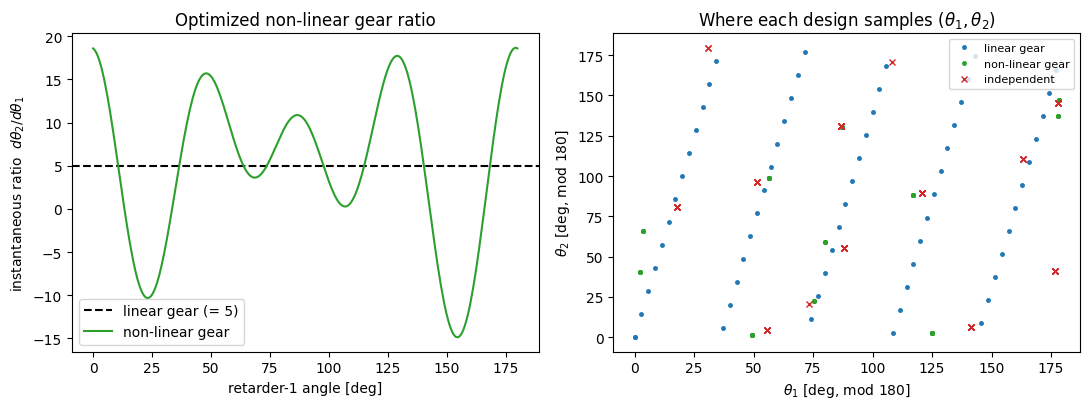

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# (left) instantaneous gear ratio vs retarder-1 angle
tt = np.linspace(0, np.pi, 300)
axes[0].axhline(GEAR, ls="--", color="k", label=f"linear gear (= {GEAR})")
axes[0].plot(np.degrees(tt), jax.device_get(gear_ratio(tt, coeffs_G)),
             color="C2", label="non-linear gear")
axes[0].set_xlabel("retarder-1 angle [deg]")
axes[0].set_ylabel(r"instantaneous ratio  $d\theta_2/d\theta_1$")
axes[0].set_title("Optimized non-linear gear ratio")
axes[0].legend()

# (right) the (theta1, theta2) locus each design visits (wrapped mod 180 deg)
wrap = lambda a: np.degrees(np.mod(a, np.pi))
axes[1].plot(wrap(baseline), wrap(GEAR * baseline), ".", ms=5, color="C0", label="linear gear")
axes[1].plot(wrap(sched_G), wrap(gear_map(sched_G, coeffs_G)), ".", ms=5, color="C2", label="non-linear gear")
axes[1].plot(wrap(sched_I1), wrap(sched_I2), "x", ms=5, color="C3", label="independent")
axes[1].set_xlabel(r"$\theta_1$ [deg, mod 180]")
axes[1].set_ylabel(r"$\theta_2$ [deg, mod 180]")
axes[1].set_title(r"Where each design samples $(\theta_1, \theta_2)$")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## How many measurements do you actually need?

Every design so far spent a fixed budget of $N=64$ measurement states. But $N$ is a design variable too — arguably the most expensive one, since each state costs acquisition time. So: **what is the minimum number of measurements that still delivers maximal accuracy?**

With a fixed per-measurement noise $\sigma$, the Fisher information is a sum of $N$ rank-one contributions,
$$\mathbf{F}=\frac{1}{\sigma^2}\sum_{i=1}^{N}\mathbf{J}_i^\top\mathbf{J}_i+\mathbf{F}_\text{prior},\qquad \mathbf{J}_i=\frac{\partial\,m(\theta_i)}{\partial\,\mathbf{p}},$$
so two regimes are possible:

- **Too few measurements.** With fewer states than free parameters the likelihood cannot determine the instrument at all: $\mathbf{J}^\top\mathbf{J}$ is rank-deficient, the estimate collapses onto the prior, and accuracy is poor no matter how the angles are placed.
- **Enough measurements.** Once the design is full-rank, extra states only pile up more of the same information and the marginal errors fall as the textbook $1/\sqrt{N}$.

The question is where the crossover sits, and whether the *optimized* **non-linear Fourier gear** and **fully-independent** designs push it all the way down to the hard floor. We sweep $N$, re-optimizing the schedule by D-optimality at each $N$, and track the RMS marginal error and the conditioning of the likelihood Fisher.

In [14]:
def rms_sigma_deg(sched1, sched2):
    '''RMS of the marginal 1-sigma errors across the five parameters [deg].'''
    s = marginal_sigmas_deg(sched1, sched2)
    return float(np.sqrt(np.mean(s ** 2)))


def likelihood_cond(sched1, sched2):
    '''Condition number of the likelihood Fisher J^T J (no prior) -> identifiability.'''
    J = jax.jacrev(lambda v: predict(v, sched1, sched2))(nominal)
    w = np.linalg.eigvalsh(J.T @ J)
    return float(w[-1] / np.clip(w[0], 1e-30, None))


Ns = [4, 5, 6, 8, 10, 12, 16, 20, 24, 32, 48, 64]
rms_fourier, rms_indep, cond_fourier, cond_indep = [], [], [], []

for n in Ns:
    base_n = np.linspace(0, np.pi, n)

    # Non-linear Fourier gear: n retarder-1 angles + 2K gear coefficients
    xg = run_adam(lambda p: neg_logdet_pair(p[:n], gear_map(p[:n], p[n:])),
                  np.concatenate([base_n, np.zeros(2 * K)]), steps=1000)
    g1, g2 = xg[:n], gear_map(xg[:n], xg[n:])

    # Fully independent: 2n free angles
    xi = run_adam(lambda p: neg_logdet_pair(p[:n], p[n:]),
                  np.concatenate([base_n, GEAR * base_n]), steps=1000)
    i1, i2 = xi[:n], xi[n:]

    rms_fourier.append(rms_sigma_deg(g1, g2)); cond_fourier.append(likelihood_cond(g1, g2))
    rms_indep.append(rms_sigma_deg(i1, i2));   cond_indep.append(likelihood_cond(i1, i2))

n_param = len(order)
print(f"free parameters to fit: {n_param}\n")
print(f"{'N':>3} {'Fourier rms[deg]':>17} {'indep rms[deg]':>15} {'rms*sqrt(N)':>13} {'like. cond':>12}")
for n, rf, ri, cf in zip(Ns, rms_fourier, rms_indep, cond_fourier):
    flag = "  <- rank-deficient" if n < n_param else ""
    print(f"{n:3d} {rf:17.3f} {ri:15.3f} {rf * n ** 0.5:13.3f} {cf:12.1e}{flag}")

free parameters to fit: 5

  N  Fourier rms[deg]  indep rms[deg]   rms*sqrt(N)   like. cond
  4             5.299           5.272        10.599      1.9e+16  <- rank-deficient
  5             1.572           1.909         3.516      1.8e+01
  6             1.488           1.453         3.645      3.1e+01
  8             1.275           1.285         3.606      3.0e+01
 10             1.117           1.102         3.533      2.5e+01
 12             1.037           1.031         3.592      2.7e+01
 16             0.898           0.879         3.591      2.8e+01
 20             0.789           0.776         3.527      2.4e+01
 24             0.723           0.712         3.541      2.5e+01
 32             0.625           0.622         3.535      2.4e+01
 48             0.520           0.508         3.600      2.8e+01
 64             0.452           0.439         3.616      2.9e+01


### The minimum is the parameter count

The result is unambiguous, and the plot below makes it visual. With five free instrument parameters, **$N=5$ is the floor**: at $N=4$ the likelihood Fisher is singular (condition number $\sim\!10^{16}$) and the RMS error is stuck near the prior width (~5°); at $N=5$ the design snaps to well-conditioned (condition number ~20) with RMS error ~1.5–1.9°, and it stays well-conditioned for every larger $N$.

Above the floor there is **no special larger $N$ that "unlocks" extra accuracy**. The efficiency $\sigma_\text{RMS}\sqrt{N}$ is flat — about $3.5^\circ\!\cdot\!\sqrt{\text{states}}$ — all the way from $N=5$ to $N=64$, which is exactly the $\sigma\propto1/\sqrt{N}$ law: every measurement past the fifth contributes the same information and simply beats down the noise. So the minimum number of measurements that maximizes accuracy is the **parameter count itself, $N^\star=5$**; beyond it you are trading acquisition time for $1/\sqrt{N}$ noise reduction — a cost/benefit call, not a conditioning one. (Want to *halve* the error? That is $4\times$ the measurements, at any point on the curve.)

Two practical notes. First, the **Fourier gear and the fully-independent design are indistinguishable** here — both reach identifiability at $N=5$ and ride the same $1/\sqrt{N}$ frontier — so the gearing constraint costs nothing in *how many* measurements you need. Second, this floor is the count of parameters you *chose to fit*: fixing the gauge (dropping the generator-polarizer axis) is exactly what lowered it from six to five. A model with more free parameters would push the floor up one-for-one.

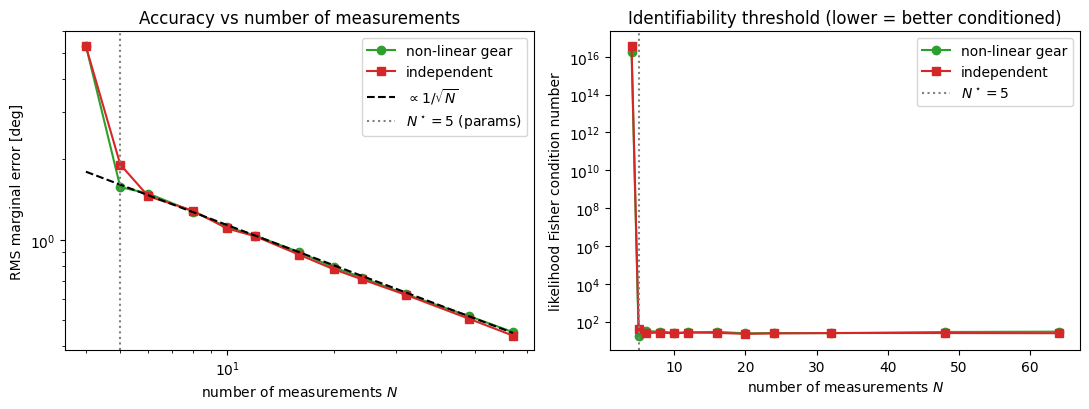

In [15]:
# 1/sqrt(N) reference, anchored to the median efficiency of the full-rank designs
eff = [rf * n ** 0.5 for n, rf in zip(Ns, rms_fourier) if n >= n_param]
C = sorted(eff)[len(eff) // 2]
ref = [C / n ** 0.5 for n in Ns]

# a singular matrix's condition number is formally infinite; cap for display
cap = 1e18
cond_f_plot = [min(c, cap) for c in cond_fourier]
cond_i_plot = [min(c, cap) for c in cond_indep]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# (left) accuracy vs number of measurements
axes[0].loglog(Ns, rms_fourier, "o-", color="C2", label="non-linear gear")
axes[0].loglog(Ns, rms_indep, "s-", color="C3", label="independent")
axes[0].loglog(Ns, ref, "k--", label=r"$\propto 1/\sqrt{N}$")
axes[0].axvline(n_param, color="grey", ls=":", label=f"$N^\\star={n_param}$ (params)")
axes[0].set_xlabel("number of measurements $N$")
axes[0].set_ylabel("RMS marginal error [deg]")
axes[0].set_title("Accuracy vs number of measurements")
axes[0].legend()

# (right) identifiability: condition number of the likelihood Fisher
axes[1].semilogy(Ns, cond_f_plot, "o-", color="C2", label="non-linear gear")
axes[1].semilogy(Ns, cond_i_plot, "s-", color="C3", label="independent")
axes[1].axvline(n_param, color="grey", ls=":", label=f"$N^\\star={n_param}$")
axes[1].set_xlabel("number of measurements $N$")
axes[1].set_ylabel("likelihood Fisher condition number")
axes[1].set_title("Identifiability threshold (lower = better conditioned)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Confirming the payoff with the full posterior

The Fisher matrix is only the Gaussian (Laplace) approximation to the covariance. To confirm that the optimized designs really do tighten the posterior, we run the *same* Bayesian calibration as the companion notebook under three designs — the **baseline** uniform sweep, the **D-optimal linear-gear** schedule, and the **non-linear gear** — and compare the sampled marginals.

For each design we simulate a noisy air measurement from the nominal instrument (using the **same** PRNG key so the comparison is apples-to-apples), then sample the five-parameter posterior with `blackjax` NUTS.

In [16]:
def simulate_and_sample(sched1, sched2, key, num_warmup=400, num_samples=2000):
    # Simulate a noisy air measurement from the nominal instrument.
    truth_power = predict(nominal, sched1, sched2)
    key, noise_key = jax.random.split(key)
    data = truth_power + sigma * jax.random.normal(noise_key, truth_power.shape)

    def log_posterior(p):
        pvec = np.array([p[k] for k in order])
        observed = predict(pvec, sched1, sched2)
        log_like = -0.5 * np.sum(((observed - data) / sigma) ** 2)
        log_prior = sum(-0.5 * ((p[k] - prior_mu[k]) / prior_sigma) ** 2 for k in p)
        return log_like + log_prior

    init = {k: np.array(v) for k, v in prior_mu.items()}
    key, warmup_key = jax.random.split(key)
    warmup = blackjax.window_adaptation(
        blackjax.nuts, log_posterior, target_acceptance_rate=0.8
    )
    (last_state, tuned), _ = warmup.run(warmup_key, init, num_steps=num_warmup)
    nuts = blackjax.nuts(log_posterior, **tuned)

    def one_step(state, k):
        state, _ = nuts.step(k, state)
        return state, state.position

    key, sample_key = jax.random.split(key)
    keys = jax.random.split(sample_key, num_samples)
    _, positions = jax.lax.scan(one_step, last_state, keys)
    return positions


# Same PRNG key for all designs, so differences come from the design, not the noise.
samples_base = simulate_and_sample(baseline, GEAR * baseline, jax.random.PRNGKey(0))
samples_D = simulate_and_sample(sched_D, GEAR * sched_D, jax.random.PRNGKey(0))
samples_G = simulate_and_sample(sched_G, gear_map(sched_G, coeffs_G), jax.random.PRNGKey(0))

print(f"\n{'parameter':28s} {'baseline':>9s} {'D-optimal':>10s} {'nonlin gear':>12s}   (NUTS 1-sigma [deg])")
for k in order:
    s0 = float(np.degrees(np.std(samples_base[k])))
    sD = float(np.degrees(np.std(samples_D[k])))
    sG = float(np.degrees(np.std(samples_G[k])))
    print(f"  {k:26s} {s0:9.3f} {sD:10.3f} {sG:12.3f}")


parameter                     baseline  D-optimal  nonlin gear   (NUTS 1-sigma [deg])


  ret1.retardance                0.768      0.475        0.498
  ret1.start_angle               0.252      0.239        0.214
  ret2.retardance                0.734      0.573        0.462
  ret2.start_angle               0.577      0.487        0.453
  pol_ana.transmission_axis      0.655      0.518        0.518


## The corner plot: baseline vs optimized posteriors

Overlaying the three NUTS posteriors makes the effect visual. Both optimized designs are visibly tighter than the baseline (blue), with the retardances $\delta_1,\delta_2$ showing the largest gains. Because D-optimality shrinks the *joint* confidence volume rather than any single marginal, the non-linear gear (green) improves some directions beyond the linear-gear schedule (orange) — notably $\delta_2$ and $\theta_2$ — while leaving others essentially unchanged. Crucially, because the generator-polarizer gauge is now fixed, the start-angle and analyzer panels ($\theta_1,\theta_2,p_2$) are no longer prior-limited: they are data-constrained and shrink under the optimized designs, rather than sitting frozen at the prior width as they did in the un-gauged model. Dashed lines mark the true parameters.

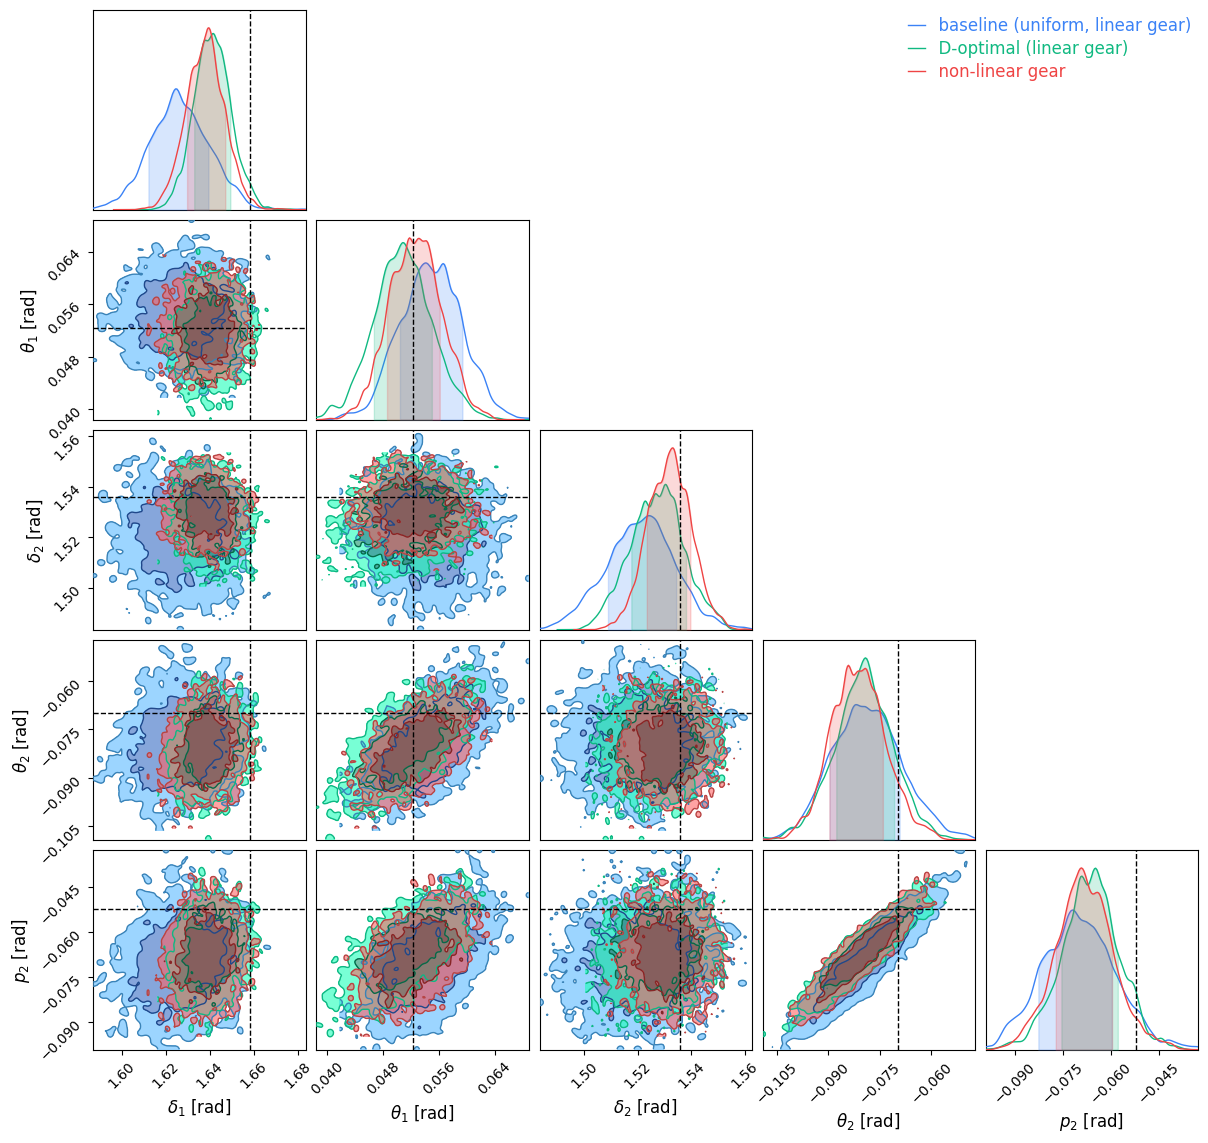

In [ ]:
from chainconsumer import ChainConsumer, Chain, Truth

labels = {
    "ret1.retardance": r"$\delta_1$ [rad]",
    "ret1.start_angle": r"$\theta_1$ [rad]",
    "ret2.retardance": r"$\delta_2$ [rad]",
    "ret2.start_angle": r"$\theta_2$ [rad]",
    "pol_ana.transmission_axis": r"$p_2$ [rad]",
}

df_base = pd.DataFrame({labels[k]: jax.device_get(samples_base[k]) for k in order})
df_D = pd.DataFrame({labels[k]: jax.device_get(samples_D[k]) for k in order})
df_G = pd.DataFrame({labels[k]: jax.device_get(samples_G[k]) for k in order})

cc = ChainConsumer()
cc.add_chain(Chain(samples=df_base, name="baseline (uniform, linear gear)"))
# cc.add_chain(Chain(samples=df_D, name="D-optimal (linear gear)"))
cc.add_chain(Chain(samples=df_G, name="non-linear gear"))
cc.add_truth(Truth(location={labels[k]: float(nominal[i]) for i, k in enumerate(order)}))
cc.plotter.plot()
plt.show()

Try out adding noise on the angle, and seeing how it affects the calibration

## Takeaways

- **Fix the gauge first.** The detected power is invariant under a global rotation of the whole instrument, so the six-parameter Fisher matrix has an exact flat direction and the four angle marginals are set by the prior, not the data. **Pinning the generator polarizer** removes it, and the start-angle and analyzer posteriors immediately drop from prior-limited ($\sim\!5.7^\circ$) to data-limited (sub-degree). Any design study that leaves this degeneracy in place is optimizing partly against an unobservable — so gauge-fix before you optimize.
- The **rotation schedule is a design variable**, and because `katsu` models are differentiable the whole parameter covariance $\mathbf{C}=\mathbf{F}^{-1}$ is a differentiable function of it. Optimizing the schedule is the *same* `optax` loop as calibration, with the rotation angles promoted to free variables.
- **A-optimality** (minimize $\operatorname{tr}\mathbf{C}$) targets the marginal bounds; **D-optimality** (maximize $\log\det\mathbf{F}$) targets the joint confidence volume. With the gauge fixed, the optimized schedule tightens *every* parameter, retardances most of all.
- **The gear ratio is a design variable too.** Relaxing the rigid $\theta_2=G\theta_1$ coupling to a **non-linear gear** $\theta_2=g(\theta_1)$ — an angle-dependent ratio, still driven by a single master rotation — shrinks the joint ellipsoid further and recovers most of the gap to fully-independent stages. The mechanism is geometric: bending the $(\theta_1,\theta_2)$ sampling curve off the straight winding line spreads the Mueller elements across more distinct harmonics. Full independence is the ceiling; the small remaining gap is the cost of keeping the stages coupled.
- **The number of measurements has a hard floor and no ceiling.** Sweeping $N$ shows the minimum useful budget is the parameter count ($N^\star=5$ here): below it the design is rank-deficient and prior-limited, at it the optimized design is already well-conditioned, and above it the RMS error simply falls as $1/\sqrt{N}$. Extra states buy generic noise reduction, not better conditioning — so choose $N$ from your error budget and acquisition-time constraints, and note that the floor drops one-for-one every time you can fix or remove a parameter.
- Because $\mathbf{F}$ depends on the unknown truth, this is **locally optimal design**: optimize at your best nominal instrument, calibrate, and iterate.